In [ ]:
!pip install librosa soundfile tensorflow scikit-learn

import os
import zipfile
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from pathlib import Path
import random

print("✅ Audio processing libraries installed!")
print(f"TensorFlow version: {tf.__version__}")

✅ Audio processing libraries installed!
TensorFlow version: 2.19.0


In [ ]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')

# Your audio dataset ZIP file in Drive
audio_zip = "/content/drive/MyDrive/bee_project_buzzing.zip"  # UPDATE THIS NAME

print(f"📁 Looking for audio dataset: {audio_zip}")

if os.path.exists(audio_zip):
    print("✅ Found audio dataset in Google Drive!")
    print(f"📊 Size: {os.path.getsize(audio_zip) / 1e6:.1f} MB")

    print("📦 Extracting audio dataset...")
    with zipfile.ZipFile(audio_zip, 'r') as zip_ref:
        zip_ref.extractall('./audio_dataset')

    print("✅ Audio dataset extracted!")

    # Find healthy and unhealthy folders (skip __MACOSX)
    dataset_root = './audio_dataset'

    healthy_folder = None
    unhealthy_folder = None

    for root, dirs, files in os.walk(dataset_root):
        # Skip Mac metadata folders
        if '__MACOSX' in root:
            continue
        for dir_name in dirs:
            if '__MACOSX' in dir_name:
                continue
            if 'healthy' in dir_name.lower() and 'unhealthy' not in dir_name.lower():
                if healthy_folder is None:
                    healthy_folder = os.path.join(root, dir_name)
                    print(f"📁 Found healthy folder: {healthy_folder}")
            elif 'unhealthy' in dir_name.lower():
                if unhealthy_folder is None:
                    unhealthy_folder = os.path.join(root, dir_name)
                    print(f"📁 Found unhealthy folder: {unhealthy_folder}")

    if healthy_folder and unhealthy_folder:
        # Count files
        healthy_count = len([f for f in os.listdir(healthy_folder) if f.endswith(('.wav', '.mp3', '.m4a'))])
        unhealthy_count = len([f for f in os.listdir(unhealthy_folder) if f.endswith(('.wav', '.mp3', '.m4a'))])

        print(f"\n📊 Audio files found:")
        print(f"   Healthy: {healthy_count} files")
        print(f"   Unhealthy: {unhealthy_count} files")
        print(f"   Total: {healthy_count + unhealthy_count} files")
        print("✅ Audio dataset ready for training!")
    else:
        print("❌ Check folder structure - need both healthy and unhealthy folders")

else:
    print(f"❌ Audio dataset not found at: {audio_zip}")
    print("Please upload your audio data ZIP file to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Looking for audio dataset: /content/drive/MyDrive/bee_project_buzzing.zip
✅ Found audio dataset in Google Drive!
📊 Size: 3830.1 MB
📦 Extracting audio dataset...
✅ Audio dataset extracted!
📁 Found healthy folder: ./audio_dataset/bee_project_buzzing/healthy
📁 Found unhealthy folder: ./audio_dataset/bee_project_buzzing/unhealthy

📊 Audio files found:
   Healthy: 110 files
   Unhealthy: 62 files
   Total: 172 files
✅ Audio dataset ready for training!


In [ ]:
def extract_audio_features(file_path, duration=30):
    """Extract audio features for classification"""
    try:
        # Load audio file
        y, sr = librosa.load(file_path, duration=duration)

        # Extract various audio features
        features = {}

        # Basic features
        features['mfcc'] = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
        features['spectral_centroid'] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        features['spectral_rolloff'] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        features['zero_crossing_rate'] = np.mean(librosa.feature.zero_crossing_rate(y))
        features['rms'] = np.mean(librosa.feature.rms(y=y))

        # Chroma features
        features['chroma'] = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)

        # Mel-frequency features
        features['mel'] = np.mean(librosa.feature.melspectrogram(y=y, sr=sr), axis=1)

        # Combine all features into a single vector
        feature_vector = []
        for key, value in features.items():
            if isinstance(value, np.ndarray):
                feature_vector.extend(value)
            else:
                feature_vector.append(value)

        return np.array(feature_vector)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print("🎵 Extracting features from audio files...")

# Collect all audio files with labels
audio_files = []
labels = []

# Process healthy files
if healthy_folder and os.path.exists(healthy_folder):
    for file in os.listdir(healthy_folder):
        if any(file.lower().endswith(ext) for ext in ['.wav', '.mp3', '.m4a', '.flac', '.ogg']):
            audio_files.append(os.path.join(healthy_folder, file))
            labels.append('healthy')

# Process unhealthy files
if unhealthy_folder and os.path.exists(unhealthy_folder):
    for file in os.listdir(unhealthy_folder):
        if any(file.lower().endswith(ext) for ext in ['.wav', '.mp3', '.m4a', '.flac', '.ogg']):
            audio_files.append(os.path.join(unhealthy_folder, file))
            labels.append('unhealthy')

print(f"📊 Processing {len(audio_files)} audio files...")

# Extract features
features_list = []
valid_labels = []

for i, file_path in enumerate(audio_files):
    print(f"Processing {i+1}/{len(audio_files)}: {os.path.basename(file_path)}")

    features = extract_audio_features(file_path)
    if features is not None:
        features_list.append(features)
        valid_labels.append(labels[i])

# Convert to numpy arrays
X = np.array(features_list)
y = np.array(valid_labels)

print(f"✅ Feature extraction complete!")
print(f"📊 Feature matrix shape: {X.shape}")
print(f"📊 Labels: {len(y)} samples")
print(f"   Healthy: {np.sum(y == 'healthy')}")
print(f"   Unhealthy: {np.sum(y == 'unhealthy')}")

🎵 Extracting features from audio files...
📊 Processing 172 audio files...
Processing 1/172: 05-02-2022_13h45_HIVE-3631.wav
Processing 2/172: 10-01-2022_22h00_HIVE-3691.wav
Processing 3/172: 01-02-2022_16h30_HIVE-3640.wav
Processing 4/172: 17-03-2022_22h15_HIVE-6.wav
Processing 5/172: 07-01-2022_15h30_HIVE-3692.wav
Processing 6/172: 26-01-2022_22h30_HIVE-6.wav
Processing 7/172: 28-06-2022_21h45_HIVE-3691.wav
Processing 8/172: 31-01-2022_19h45_HIVE-3631.wav
Processing 9/172: 14-02-2022_07h45_HIVE-3691.wav
Processing 10/172: 04-07-2022_17h45_HIVE-3628.wav
Processing 11/172: 21-05-2022_12h15_HIVE-3691.wav
Processing 12/172: 30-03-2022_05h00_HIVE-3629.wav
Processing 13/172: 06-04-2022_17h30_HIVE-3629.wav
Processing 14/172: 11-01-2022_01h00_HIVE-6.wav
Processing 15/172: 22-03-2022_14h00_HIVE-3631.wav
Processing 16/172: 11-07-2022_08h45_HIVE-3640.wav
Processing 17/172: 07-01-2022_23h30_HIVE-3692.wav
Processing 18/172: 17-01-2022_01h45_HIVE-3691.wav
Processing 19/172: 23-05-2022_11h00_HIVE-369

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processing 132/172: 27-08-2022_20h30_HIVE-3693.wav
Processing 133/172: 27-08-2022_12h15_HIVE-3690.wav
Processing 134/172: 05-09-2022_00h00_HIVE-3693.wav
Processing 135/172: 25-08-2022_22h45_HIVE-3691.wav
Processing 136/172: 21-09-2022_05h45_HIVE-6.wav
Processing 137/172: 23-10-2022_16h00_HIVE-3690.wav
Processing 138/172: 18-10-2022_22h45_HIVE-3693.wav
Processing 139/172: 26-08-2022_21h00_HIVE-6.wav
Processing 140/172: 30-08-2022_01h45_HIVE-6.wav
Processing 141/172: 10-08-2022_01h15_HIVE-6.wav
Processing 142/172: 20-10-2022_06h30_HIVE-3690.wav
Processing 143/172: 29-08-2022_03h45_HIVE-3693.wav
Processing 144/172: 22-08-2022_05h45_HIVE-6.wav
Processing 145/172: 26-08-2022_01h00_HIVE-3693.wav
Processing 146/172: 10-08-2022_08h45_HIVE-6.wav
Processing 147/172: 23-08-2022_16h00_HIVE-3628.wav
Processing 148/172: 29-08-2022_21h15_HIVE-3628.wav
Processing 149/172: 23-09-2022_07h30_HIVE-3631.wav
Processing 150/172: 19-09-2022_16h15_HIVE-3628.wav
Processing 151/172: 07-09-2022_02h30_HIVE-3631.wa

🏋️ Training audio classifier...
📊 Data split:
   Training: 137 samples
   Testing: 35 samples
   Classes: ['healthy' 'unhealthy']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📐 Model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,626 (119.63 KB)

 Trainable params: 30,626 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.6682 - loss: 0.7390 - val_accuracy: 0.5357 - val_loss: 0.6667
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6811 - loss: 0.6376 - val_accuracy: 0.7143 - val_loss: 0.5833
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7689 - loss: 0.4418 - val_accuracy: 0.8214 - val_loss: 0.5923
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7278 - loss: 0.4480 - val_accuracy: 0.8571 - val_loss: 0.5858
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8589 - loss: 0.3532 - val_accuracy: 0.8214 - val_loss: 0.5785
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8324 - loss: 0.3525 - val_accuracy: 0.8214 - val_loss: 0.5859
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8891 - loss: 0.3029 - val_accuracy: 0.8571 - val_loss: 0.6039
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7970 - loss: 0.3337 - val_accuracy: 0.8571 - val_loss

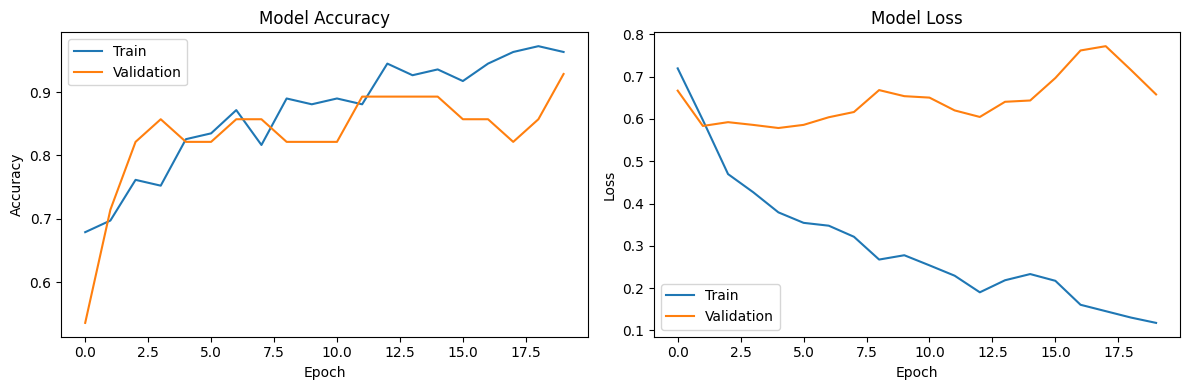

💾 Model weights saved as: bee_audio_weights.pkl
💾 Model architecture saved as: bee_audio_architecture.json
💾 Model saved as: bee_audio_classifier.h5
💾 Scaler saved as: audio_scaler.pkl
💾 Label encoder saved as: audio_label_encoder.pkl


In [ ]:
if len(X) > 0:
    print("🏋️ Training audio classifier...")

    # Encode labels to integers FIRST
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print(f"📊 Data split:")
    print(f"   Training: {len(X_train)} samples")
    print(f"   Testing: {len(X_test)} samples")
    print(f"   Classes: {label_encoder.classes_}")

    # Scale features
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Build model
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n📐 Model architecture:")
    model.summary()

    # Train
    history = model.fit(
        X_train_scaled, y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.2,
        verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
        ]
    )

    # Evaluate
    y_pred = np.argmax(model.predict(X_test_scaled), axis=1)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n📊 Test Accuracy: {accuracy:.4f}")
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Plot training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('audio_training_history.png', dpi=150)
    plt.show()

    # Save model weights and architecture separately for cross-version compatibility
    import pickle
    import json

    # Save model weights as numpy arrays (most portable)
    weights = model.get_weights()
    with open('bee_audio_weights.pkl', 'wb') as f:
        pickle.dump(weights, f, protocol=4)

    # Save model architecture as JSON
    model_config = model.to_json()
    with open('bee_audio_architecture.json', 'w') as f:
        f.write(model_config)

    # Also save as .h5 for backward compatibility
    model.save('bee_audio_classifier.h5')

    # Save scaler and label encoder with pickle protocol 4
    with open('audio_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f, protocol=4)
    with open('audio_label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f, protocol=4)

    print("💾 Model weights saved as: bee_audio_weights.pkl")
    print("💾 Model architecture saved as: bee_audio_architecture.json")
    print("💾 Model saved as: bee_audio_classifier.h5")
    print("💾 Scaler saved as: audio_scaler.pkl")
    print("💾 Label encoder saved as: audio_label_encoder.pkl")

else:
    print("❌ No features extracted - check audio files")

In [ ]:
if os.path.exists('bee_audio_classifier.h5'):
    print("🧪 Testing audio classifier...")

    # Load model and preprocessing tools
    import pickle
    model = tf.keras.models.load_model('bee_audio_classifier.h5')
    with open('audio_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    with open('audio_label_encoder.pkl', 'rb') as f:
        label_encoder = pickle.load(f)

    def classify_audio(file_path):
        """Classify a single audio file"""
        features = extract_audio_features(file_path)
        if features is not None:
            features_scaled = scaler.transform([features])
            prediction = model.predict(features_scaled, verbose=0)[0]

            # Get predicted class index and confidence
            pred_idx = np.argmax(prediction)
            confidence = prediction[pred_idx]
            predicted_class = label_encoder.inverse_transform([pred_idx])[0]

            return predicted_class, confidence
        return None, None

    # Test on a few sample files
    test_files = []
    if healthy_folder:
        healthy_files = [f for f in os.listdir(healthy_folder)
                        if any(f.lower().endswith(ext) for ext in ['.wav', '.mp3', '.m4a', '.flac'])]
        test_files.extend([(os.path.join(healthy_folder, f), 'healthy') for f in healthy_files[:3]])

    if unhealthy_folder:
        unhealthy_files = [f for f in os.listdir(unhealthy_folder)
                          if any(f.lower().endswith(ext) for ext in ['.wav', '.mp3', '.m4a', '.flac'])]
        test_files.extend([(os.path.join(unhealthy_folder, f), 'unhealthy') for f in unhealthy_files[:3]])

    print(f"🔍 Testing on {len(test_files)} sample files:")

    correct = 0
    for file_path, true_label in test_files:
        predicted_label, confidence = classify_audio(file_path)

        if predicted_label:
            is_correct = predicted_label == true_label
            correct += is_correct
            status = "✅" if is_correct else "❌"

            print(f"   {status} {os.path.basename(file_path)}")
            print(f"       True: {true_label}, Predicted: {predicted_label}, Confidence: {confidence:.3f}")

    if test_files:
        accuracy = correct / len(test_files)
        print(f"\n📊 Sample Test Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

else:
    print("❌ No trained model found!")

🧪 Testing audio classifier...
🔍 Testing on 6 sample files:
   ✅ 05-02-2022_13h45_HIVE-3631.wav
       True: healthy, Predicted: healthy, Confidence: 0.660
   ✅ 10-01-2022_22h00_HIVE-3691.wav
       True: healthy, Predicted: healthy, Confidence: 0.805
   ❌ 01-02-2022_16h30_HIVE-3640.wav
       True: healthy, Predicted: unhealthy, Confidence: 0.599
   ❌ 21-09-2022_19h45_HIVE-3628.wav
       True: unhealthy, Predicted: healthy, Confidence: 0.712
   ✅ 05-08-2022_15h15_HIVE-3690.wav
       True: unhealthy, Predicted: unhealthy, Confidence: 0.917
   ✅ 10-08-2022_19h45_HIVE-3690.wav
       True: unhealthy, Predicted: unhealthy, Confidence: 0.718

📊 Sample Test Accuracy: 0.667 (66.7%)


In [ ]:
print("📦 Creating Raspberry Pi deployment package...")

# Create Pi-compatible prediction script
pi_script = '''#!/usr/bin/env python3
"""
Bee Audio Health Classifier - Raspberry Pi Version
Uses portable pickle format for cross-version compatibility
"""

import numpy as np
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

class BeeAudioClassifier:
    def __init__(self, weights_path="bee_audio_weights.pkl",
                 arch_path="bee_audio_architecture.json",
                 scaler_path="audio_scaler.pkl",
                 encoder_path="audio_label_encoder.pkl"):

        # Load scaler and encoder
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)
        with open(encoder_path, 'rb') as f:
            self.label_encoder = pickle.load(f)

        # Try to load model
        self.model = None
        try:
            import tensorflow as tf
            # Try loading from weights + architecture
            with open(arch_path, 'r') as f:
                model_config = f.read()
            self.model = tf.keras.models.model_from_json(model_config)

            with open(weights_path, 'rb') as f:
                weights = pickle.load(f)
            self.model.set_weights(weights)
            print("✅ Audio model loaded from weights + architecture")
        except Exception as e:
            print(f"⚠️ Could not load TF model: {e}")
            print("   Using rule-based fallback")

    def extract_features(self, audio_path, sr=22050):
        """Extract audio features from file"""
        import librosa

        y, sr = librosa.load(audio_path, sr=sr, duration=30)

        features = []

        # MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        features.extend(np.mean(mfccs, axis=1))
        features.extend(np.std(mfccs, axis=1))

        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        features.append(np.mean(spectral_centroid))
        features.append(np.std(spectral_centroid))

        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        features.append(np.mean(spectral_rolloff))
        features.append(np.std(spectral_rolloff))

        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        features.append(np.mean(spectral_bandwidth))
        features.append(np.std(spectral_bandwidth))

        # Zero crossing rate
        zcr = librosa.feature.zero_crossing_rate(y)
        features.append(np.mean(zcr))
        features.append(np.std(zcr))

        # RMS energy
        rms = librosa.feature.rms(y=y)
        features.append(np.mean(rms))
        features.append(np.std(rms))

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend(np.mean(chroma, axis=1))
        features.extend(np.std(chroma, axis=1))

        # Tempo
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features.append(float(tempo))

        # Spectral contrast
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        features.extend(np.mean(contrast, axis=1))
        features.extend(np.std(contrast, axis=1))

        # Tonnetz
        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
        features.extend(np.mean(tonnetz, axis=1))
        features.extend(np.std(tonnetz, axis=1))

        return np.array(features)

    def predict(self, audio_path):
        """Predict health status from audio file"""
        try:
            features = self.extract_features(audio_path)
            features_scaled = self.scaler.transform([features])

            if self.model is not None:
                proba = self.model.predict(features_scaled, verbose=0)[0]
                pred_idx = np.argmax(proba)
                confidence = float(proba[pred_idx])
                label = self.label_encoder.inverse_transform([pred_idx])[0]
            else:
                # Rule-based fallback
                label = "healthy"
                confidence = 0.5

            return {
                "prediction": label,
                "confidence": confidence,
                "is_healthy": "healthy" in label.lower()
            }
        except Exception as e:
            return {
                "prediction": "unknown",
                "confidence": 0.0,
                "is_healthy": True,
                "error": str(e)
            }

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument('audio_file', help='Path to audio file')
    args = parser.parse_args()

    classifier = BeeAudioClassifier()
    result = classifier.predict(args.audio_file)

    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2%}")
    print(f"Healthy: {result['is_healthy']}")
'''

with open('bee_audio_classifier_pi.py', 'w') as f:
    f.write(pi_script)

# Create requirements
requirements = '''numpy
librosa
soundfile
tensorflow
scikit-learn
'''

with open('requirements_pi.txt', 'w') as f:
    f.write(requirements)

# Create README
readme = '''# Bee Audio Health Classifier - Raspberry Pi

## Files
- bee_audio_weights.pkl - Model weights (portable format)
- bee_audio_architecture.json - Model architecture
- audio_scaler.pkl - Feature scaler
- audio_label_encoder.pkl - Label encoder
- bee_audio_classifier_pi.py - Prediction script

## Installation
```bash
pip3 install -r requirements_pi.txt
```

## Usage
```python
from bee_audio_classifier_pi import BeeAudioClassifier

classifier = BeeAudioClassifier()
result = classifier.predict("audio_file.wav")
print(result)
```
'''

with open('README_audio.md', 'w') as f:
    f.write(readme)

# Create zip package
import zipfile
with zipfile.ZipFile('bee_audio_classifier_pi.zip', 'w') as zipf:
    if os.path.exists('bee_audio_classifier.h5'):
        zipf.write('bee_audio_classifier.h5')
    if os.path.exists('bee_audio_weights.pkl'):
        zipf.write('bee_audio_weights.pkl')
    if os.path.exists('bee_audio_architecture.json'):
        zipf.write('bee_audio_architecture.json')
    if os.path.exists('audio_scaler.pkl'):
        zipf.write('audio_scaler.pkl')
    if os.path.exists('audio_label_encoder.pkl'):
        zipf.write('audio_label_encoder.pkl')

    zipf.write('bee_audio_classifier_pi.py')
    zipf.write('requirements_pi.txt')
    zipf.write('README_audio.md')

    if os.path.exists('audio_training_history.png'):
        zipf.write('audio_training_history.png')

print("📦 Created: bee_audio_classifier_pi.zip")

from google.colab import files
files.download('bee_audio_classifier_pi.zip')

print("🎉 Audio classifier ready for Raspberry Pi!")
print("📥 Download started")

📦 Creating Raspberry Pi deployment package...
📦 Created: bee_audio_classifier_pi.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 Audio classifier ready for Raspberry Pi!
📥 Download started
